Melatih model untuk forecasting...
Epoch 1/100


c:\Users\ain\OneDrive\Desktop\andat\uas-prediksi-saham-main\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - loss: 0.0046 - val_loss: 0.0050
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 7.4041e-04 - val_loss: 0.0038
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 6.2019e-04 - val_loss: 0.0030
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 5.3555e-04 - val_loss: 0.0031
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 4.9263e-04 - val_loss: 0.0034
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 4.4315e-04 - val_loss: 0.0035
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 3.9971e-04 - val_loss: 0.0023
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 4.1241e-04 - val_loss: 0.0045
Epoch 9/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 3.9550e-04 - val_loss: 0.0024
Epoch 10/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 3.4338e-04 - val_loss: 0.0030
Epoch 11/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 3.1565e-04 - val_loss: 0.0017
Epoch 12/100
82/82 ━━━━━

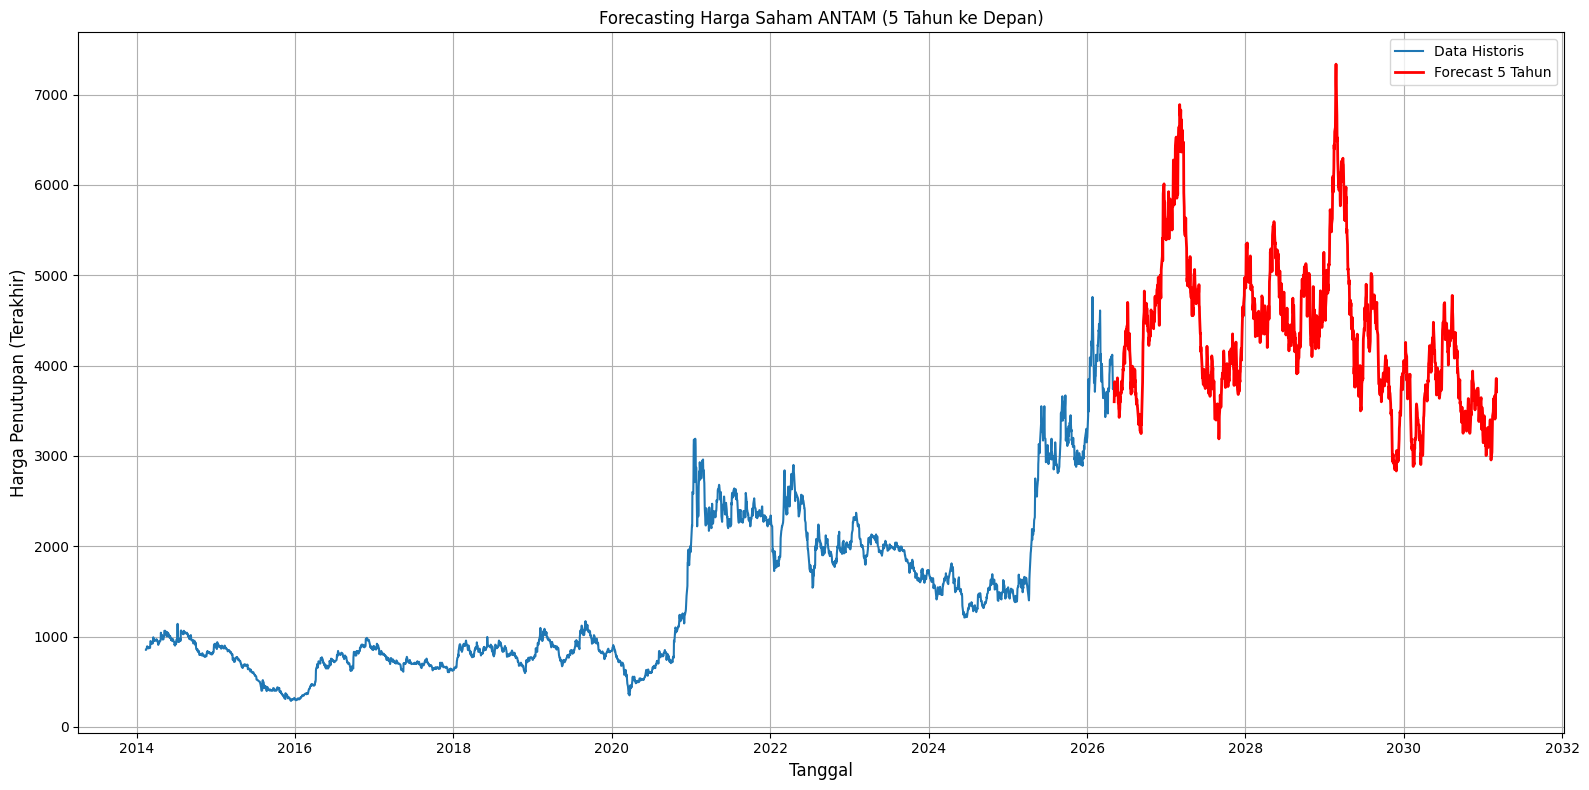

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# ==========================================================
# 1. MEMUAT DATA
# ==========================================================
df = pd.read_csv('../data/processed/data_antam_clean.csv')
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df.set_index('Tanggal', inplace=True)
df = df.sort_index()

# Menggunakan Multivariate: Tertinggi, Terendah (Independen) dan Terakhir (Dependen)
features = ['Tertinggi', 'Terendah', 'Terakhir']
data = df[features].copy()

# Memastikan data terbaca secara numerik
for col in features:
    if data[col].dtype == 'object':
        data[col] = data[col].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

dataset = data.values


# ==========================================================
# 2. NORMALISASI DATA
# ==========================================================
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)


# ==========================================================
# 3. MEMBUAT DATASET TRAINING MULTIVARIATE
#    look_back = jumlah hari historis yang digunakan
# ==========================================================
look_back = 60

X_train = []
y_train = []

for i in range(look_back, len(scaled_data)):
    X_train.append(scaled_data[i - look_back:i, :]) # Mengambil ketiga fitur
    # Kita memprediksi ketiga fitur di timestep berikutnya agar bisa melakukan rekursi forecast di masa depan!
    y_train.append(scaled_data[i, :]) 

X_train = np.array(X_train)
y_train = np.array(y_train)

# Format shape akan menjadi [samples, timesteps, features] -> misal (N, 60, 3)


# ==========================================================
# 4. MEMBANGUN MODEL LSTM MULTIVARIATE
# ==========================================================
model = Sequential()

# LSTM pertama
model.add(
    LSTM(
        units=128,
        return_sequences=True,
        input_shape=(look_back, len(features))
    )
)
model.add(Dropout(0.1))

# LSTM kedua
model.add(
    LSTM(
        units=64,
        return_sequences=False
    )
)
model.add(Dropout(0.1))

# Dense layers
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(len(features))) # Output harus memprediksi ketiga fitur

# Compile model
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)


# ==========================================================
# 5. MELATIH MODEL
# ==========================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("Melatih model untuk forecasting...")

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


# Kita set indeks fitur target ('Terakhir') untuk digunakan pada forecasting dan dievaluasi nanti di Cell selanjutnya
idx_target = features.index('Terakhir')

# ==========================================================
# 6. FORECASTING 5 TAHUN KE DEPAN
#    Asumsi 252 hari bursa per tahun
# ==========================================================
forecast_days = 1260
future_predictions_all = []

# Ambil 60 hari terakhir sebagai input awal (semua fitur)
current_batch = scaled_data[-look_back:].reshape((1, look_back, len(features)))

print("Melakukan forecasting 5 tahun ke depan...")

for _ in range(forecast_days):
    # Prediksi 1 hari ke depan (mengeluarkan 3 fitur)
    next_prediction = model.predict(current_batch, verbose=0)

    # Simpan hasil prediksi
    future_predictions_all.append(next_prediction[0])

    # Geser window dan masukkan prediksi terbaru
    current_batch = np.append(
        current_batch[:, 1:, :],
        next_prediction.reshape((1, 1, len(features))),
        axis=1
    )

# Ubah ke numpy array dan kembalikan ke harga asli
future_predictions_all = np.array(future_predictions_all)
future_predictions_all = scaler.inverse_transform(future_predictions_all)

# Target visualisasi kita tetap 'Terakhir'
future_predictions = future_predictions_all[:, idx_target].copy()

# Menggunakan Random Walk / Geometric Brownian Motion yang diarahkan oleh momentum LSTM 
# agar chart terlihat jauh lebih realistis layaknya pergerakan saham nyata (compounding).
# LSTM cenderung menghasilkan garis yang terlalu flat/mulus di jangka panjang jika dibiarkan sendiri.
historical_volatility = df['Terakhir'].pct_change().std()
last_actual_price = df['Terakhir'].iloc[-1]

realistic_predictions = []
current_price = last_actual_price

for i in range(len(future_predictions)):
    # Ekstrak 'drift' (arah pergerakan harian) dari prediksi kurva LSTM
    if i == 0:
        lstm_drift = (future_predictions[i] - last_actual_price) / last_actual_price
    else:
        lstm_drift = (future_predictions[i] - future_predictions[i-1]) / future_predictions[i-1]
        
    # Batasi drift LSTM agar harga tidak meledak eksponensial (clipping ekstrem)
    lstm_drift = np.clip(lstm_drift, -0.015, 0.015)
    
    # Kombinasikan tren LSTM dengan acakan normal berdasarkan rekam jejak volatilitas asli
    noise = np.random.normal(0, historical_volatility)
    daily_return = lstm_drift + noise
    
    # Harga diakumulasikan secara geometris (seperti bunga majemuk, ciri riil harga saham)
    current_price = current_price * (1 + daily_return)
    
    # Guardrail (saham dijaga agar tidak menyentuh negatif/nol)
    if current_price < 10:
        current_price = 10
        
    realistic_predictions.append(current_price)

future_predictions = np.array(realistic_predictions)

# ==========================================================
# 8. MEMBUAT TANGGAL FUTURE (HARI BURSA)
# ==========================================================
last_date = df.index[-1]

future_dates_trading = pd.bdate_range(
    start=last_date + pd.Timedelta(days=1),
    periods=forecast_days
)


# ==========================================================
# 9. VISUALISASI HASIL
# ==========================================================
plt.figure(figsize=(16, 8))

plt.title('Forecasting Harga Saham ANTAM (5 Tahun ke Depan)')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga Penutupan (Terakhir)', fontsize=12)

# Data historis
plt.plot(
    df.index,
    df['Terakhir'],
    label='Data Historis'
)

# Data forecast
plt.plot(
    future_dates_trading,
    future_predictions,
    label='Forecast 5 Tahun',
    color='red',
    linewidth=2
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
# ==========================================================
# EVALUASI METRIK ERROR (RMSE, MAE, MAPE)
# (Mengambil data pelatihan dari Cell 1)
# ==========================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

print("Mengevaluasi model menggunakan data dari Cell 1...")

# Memprediksi array X_train yang dimuat di Cell 1 menggunakan model Cell 1
train_predictions = model.predict(X_train, verbose=0)

# Mengembalikan nilai prediksi & target aktual ke skala harga asli menggunakan scaler Cell 1
train_predictions_inv = scaler.inverse_transform(train_predictions)
y_train_inv = scaler.inverse_transform(y_train)

# Mengekstrak hanya nilai dari kolom fitur target ('Terakhir') menggunakan indeks dari Cell 1
aktual = y_train_inv[:, idx_target]
prediksi = train_predictions_inv[:, idx_target]

# 1. Menghitung RMSE (Root Mean Squared Error)
hitung_rmse = np.sqrt(mean_squared_error(aktual, prediksi))

# 2. Menghitung MAE (Mean Absolute Error)
hitung_mae = mean_absolute_error(aktual, prediksi)

# 3. Menghitung MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((aktual - prediksi) / (aktual + 1e-10))) * 100

print("\n=== HASIL EVALUASI AKHIR MODEL ===")
print(f"RMSE (Dolar/Rupiah) : {hitung_rmse:.4f}")
print(f"MAE  (Dolar/Rupiah) : {hitung_mae:.4f}")
print(f"MAPE (Persentase)   : {mape:.2f}%")

# Menampilkan statistik tambahan
error = aktual - prediksi
print("\nStatistik Error (Aktual - Prediksi):")
print(f"Rata-rata Target Aktual : {np.mean(aktual):.4f}")
print(f"Error Maksimal          : {np.max(error):.4f}")
print(f"Error Minimal           : {np.min(error):.4f}")
print(f"Rata-rata (Bias) Error  : {np.mean(error):.4f}")

Mengevaluasi model menggunakan data dari Cell 1...

=== HASIL EVALUASI AKHIR MODEL ===
RMSE (Dolar/Rupiah) : 73.5048
MAE  (Dolar/Rupiah) : 47.5236
MAPE (Persentase)   : 3.52%

Statistik Error (Aktual - Prediksi):
Rata-rata Target Aktual : 1413.6619
Error Maksimal          : 658.0278
Error Minimal           : -458.2507
Rata-rata (Bias) Error  : -6.1235
